# Tournament Results Analysis

This notebook analyzes the results from the final tournament experiments, plotting scores and creating crossplay heatmaps for different noise levels.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette("husl")

# Set figure parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12


## Data Loading and Processing

First, let's explore the directory structure and load the tournament data.


In [2]:
# Define the base directory
final_dir = Path('final_2')

# Get all strategy directories
strategy_dirs = [d for d in final_dir.iterdir() if d.is_dir() and not d.name.startswith('analysis')]
strategy_dirs = sorted(strategy_dirs, key=lambda x: int(x.name.split('_')[0]))

print(f"Found {len(strategy_dirs)} strategy directories:")
for d in strategy_dirs:
    print(f"  {d.name}")

# Get noise levels from one directory
sample_rep_dir = strategy_dirs[0] / 'repetition_0'
csv_files = [f for f in sample_rep_dir.iterdir() if f.suffix == '.csv']
noise_levels = sorted([float(f.stem) for f in csv_files])
print(f"\nNoise levels: {noise_levels}")

# Number of repetitions
rep_dirs = [d for d in strategy_dirs[0].iterdir() if d.name.startswith('repetition_')]
n_repetitions = len(rep_dirs)
print(f"Number of repetitions: {n_repetitions}")


Found 15 strategy directories:
  0_DBS
  1_RiskyQLearner
  2_ArrogantQLearner
  3_CautiousQLearner
  4_HesitantQLearner
  5_JaxFiveStateAgent
  6_JaxFiveStateAgent
  7_JaxFactorizedAgent
  8_JaxFactorizedAgent
  9_APavlov2011
  10_AdaptiveTitForTat
  11_GTFT
  12_ContriteTitForTat
  13_StochasticWSLS
  14_WinStayLoseShift

Noise levels: [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45]
Number of repetitions: 5


In [3]:
def load_tournament_data():
    """
    Load all tournament data from the final directory structure.
    Returns a comprehensive DataFrame with all results.
    """
    all_data = []
    
    for strategy_dir in strategy_dirs:
        strategy_id = int(strategy_dir.name.split('_')[0])
        strategy_name = '_'.join(strategy_dir.name.split('_')[1:])
        
        print(f"Loading data for {strategy_dir.name}...")
        
        for rep in range(n_repetitions):
            rep_dir = strategy_dir / f'repetition_{rep}'
            
            # Load player names from details.json
            details_file = rep_dir / 'details.json'
            if details_file.exists():
                with open(details_file, 'r') as f:
                    details = json.load(f)
                    player_names = details['player_names']
            else:
                player_names = None
            
            for noise_level in noise_levels:
                csv_file = rep_dir / f'{noise_level}.csv'
                
                if csv_file.exists():
                    try:
                        df = pd.read_csv(csv_file)
                        
                        # Add metadata columns
                        df['strategy_id'] = strategy_id
                        df['strategy_name'] = strategy_name
                        df['testing_strategy'] = f"{strategy_id}_{strategy_name}"
                        df['noise_level'] = noise_level
                        df['repetition_id'] = rep
                        
                        # Add player names if available
                        if player_names:
                            df['player_name_clean'] = df['Player index'].map(
                                lambda x: player_names[x] if x < len(player_names) else f"Player_{x}"
                            )
                            df['opponent_name_clean'] = df['Opponent index'].map(
                                lambda x: player_names[x] if x < len(player_names) else f"Player_{x}"
                            )
                        
                        all_data.append(df)
                        
                    except Exception as e:
                        print(f"Error loading {csv_file}: {e}")
    
    # Combine all data
    full_df = pd.concat(all_data, ignore_index=True)
    print(f"\nLoaded {len(full_df)} total interactions")
    
    return full_df

# Load the data
tournament_data = load_tournament_data()


Loading data for 0_DBS...
Loading data for 1_RiskyQLearner...
Loading data for 2_ArrogantQLearner...
Loading data for 3_CautiousQLearner...
Loading data for 4_HesitantQLearner...
Loading data for 5_JaxFiveStateAgent...
Loading data for 6_JaxFiveStateAgent...
Loading data for 7_JaxFactorizedAgent...
Loading data for 8_JaxFactorizedAgent...
Loading data for 9_APavlov2011...
Loading data for 10_AdaptiveTitForTat...
Loading data for 11_GTFT...
Loading data for 12_ContriteTitForTat...
Loading data for 13_StochasticWSLS...
Loading data for 14_WinStayLoseShift...

Loaded 67500 total interactions


In [4]:
# Display basic information about the loaded data
print("Data shape:", tournament_data.shape)
print("\nColumns:", list(tournament_data.columns))
print("\nTesting strategies:")
print(tournament_data['testing_strategy'].unique())
print("\nNoise levels:", sorted(tournament_data['noise_level'].unique()))
print("\nRepetitions:", sorted(tournament_data['repetition_id'].unique()))


Data shape: (67500, 36)

Columns: ['Interaction index', 'Player index', 'Opponent index', 'Repetition', 'Player name', 'Opponent name', 'Actions', 'Score', 'Score difference', 'Turns', 'Score per turn', 'Score difference per turn', 'Win', 'Initial cooperation', 'Cooperation count', 'CC count', 'CD count', 'DC count', 'DD count', 'CC to C count', 'CC to D count', 'CD to C count', 'CD to D count', 'DC to C count', 'DC to D count', 'DD to C count', 'DD to D count', 'Good partner', 'Intended Actions', 'strategy_id', 'strategy_name', 'testing_strategy', 'noise_level', 'repetition_id', 'player_name_clean', 'opponent_name_clean']

Testing strategies:
['0_DBS' '1_RiskyQLearner' '2_ArrogantQLearner' '3_CautiousQLearner'
 '4_HesitantQLearner' '5_JaxFiveStateAgent' '6_JaxFiveStateAgent'
 '7_JaxFactorizedAgent' '8_JaxFactorizedAgent' '9_APavlov2011'
 '10_AdaptiveTitForTat' '11_GTFT' '12_ContriteTitForTat'
 '13_StochasticWSLS' '14_WinStayLoseShift']

Noise levels: [np.float64(0.0), np.float64(0.05)

## Score Analysis

Now let's analyze the scores of each testing strategy against the strategy pool.


In [5]:
def calculate_average_scores():
    """
    Calculate average scores for each testing strategy across all repetitions and opponents.
    """
    # Filter to only include the testing strategy's performance (Player index = 0)
    testing_performance = tournament_data[tournament_data['Player index'] == 0].copy()
    
    # Calculate average scores per testing strategy, noise level, and opponent
    avg_scores = testing_performance.groupby([
        'testing_strategy', 'noise_level', 'Opponent index', 'opponent_name_clean'
    ]).agg({
        'Score': 'mean',
        'Score per turn': 'mean',
        'Win': 'mean',
        'Cooperation count': 'mean',
        'Turns': 'mean'
    }).reset_index()
    
    # Calculate overall average across all opponents for each testing strategy and noise level
    overall_avg = testing_performance.groupby([
        'testing_strategy', 'noise_level'
    ]).agg({
        'Score': 'mean',
        'Score per turn': 'mean', 
        'Win': 'mean',
        'Cooperation count': 'mean'
    }).reset_index()
    
    return avg_scores, overall_avg

avg_scores_detailed, avg_scores_overall = calculate_average_scores()

print("Average scores calculated!")
print(f"Detailed averages shape: {avg_scores_detailed.shape}")
print(f"Overall averages shape: {avg_scores_overall.shape}")


Average scores calculated!
Detailed averages shape: (1350, 9)
Overall averages shape: (150, 6)


## Plot 1: Average Scores vs Strategy Pool


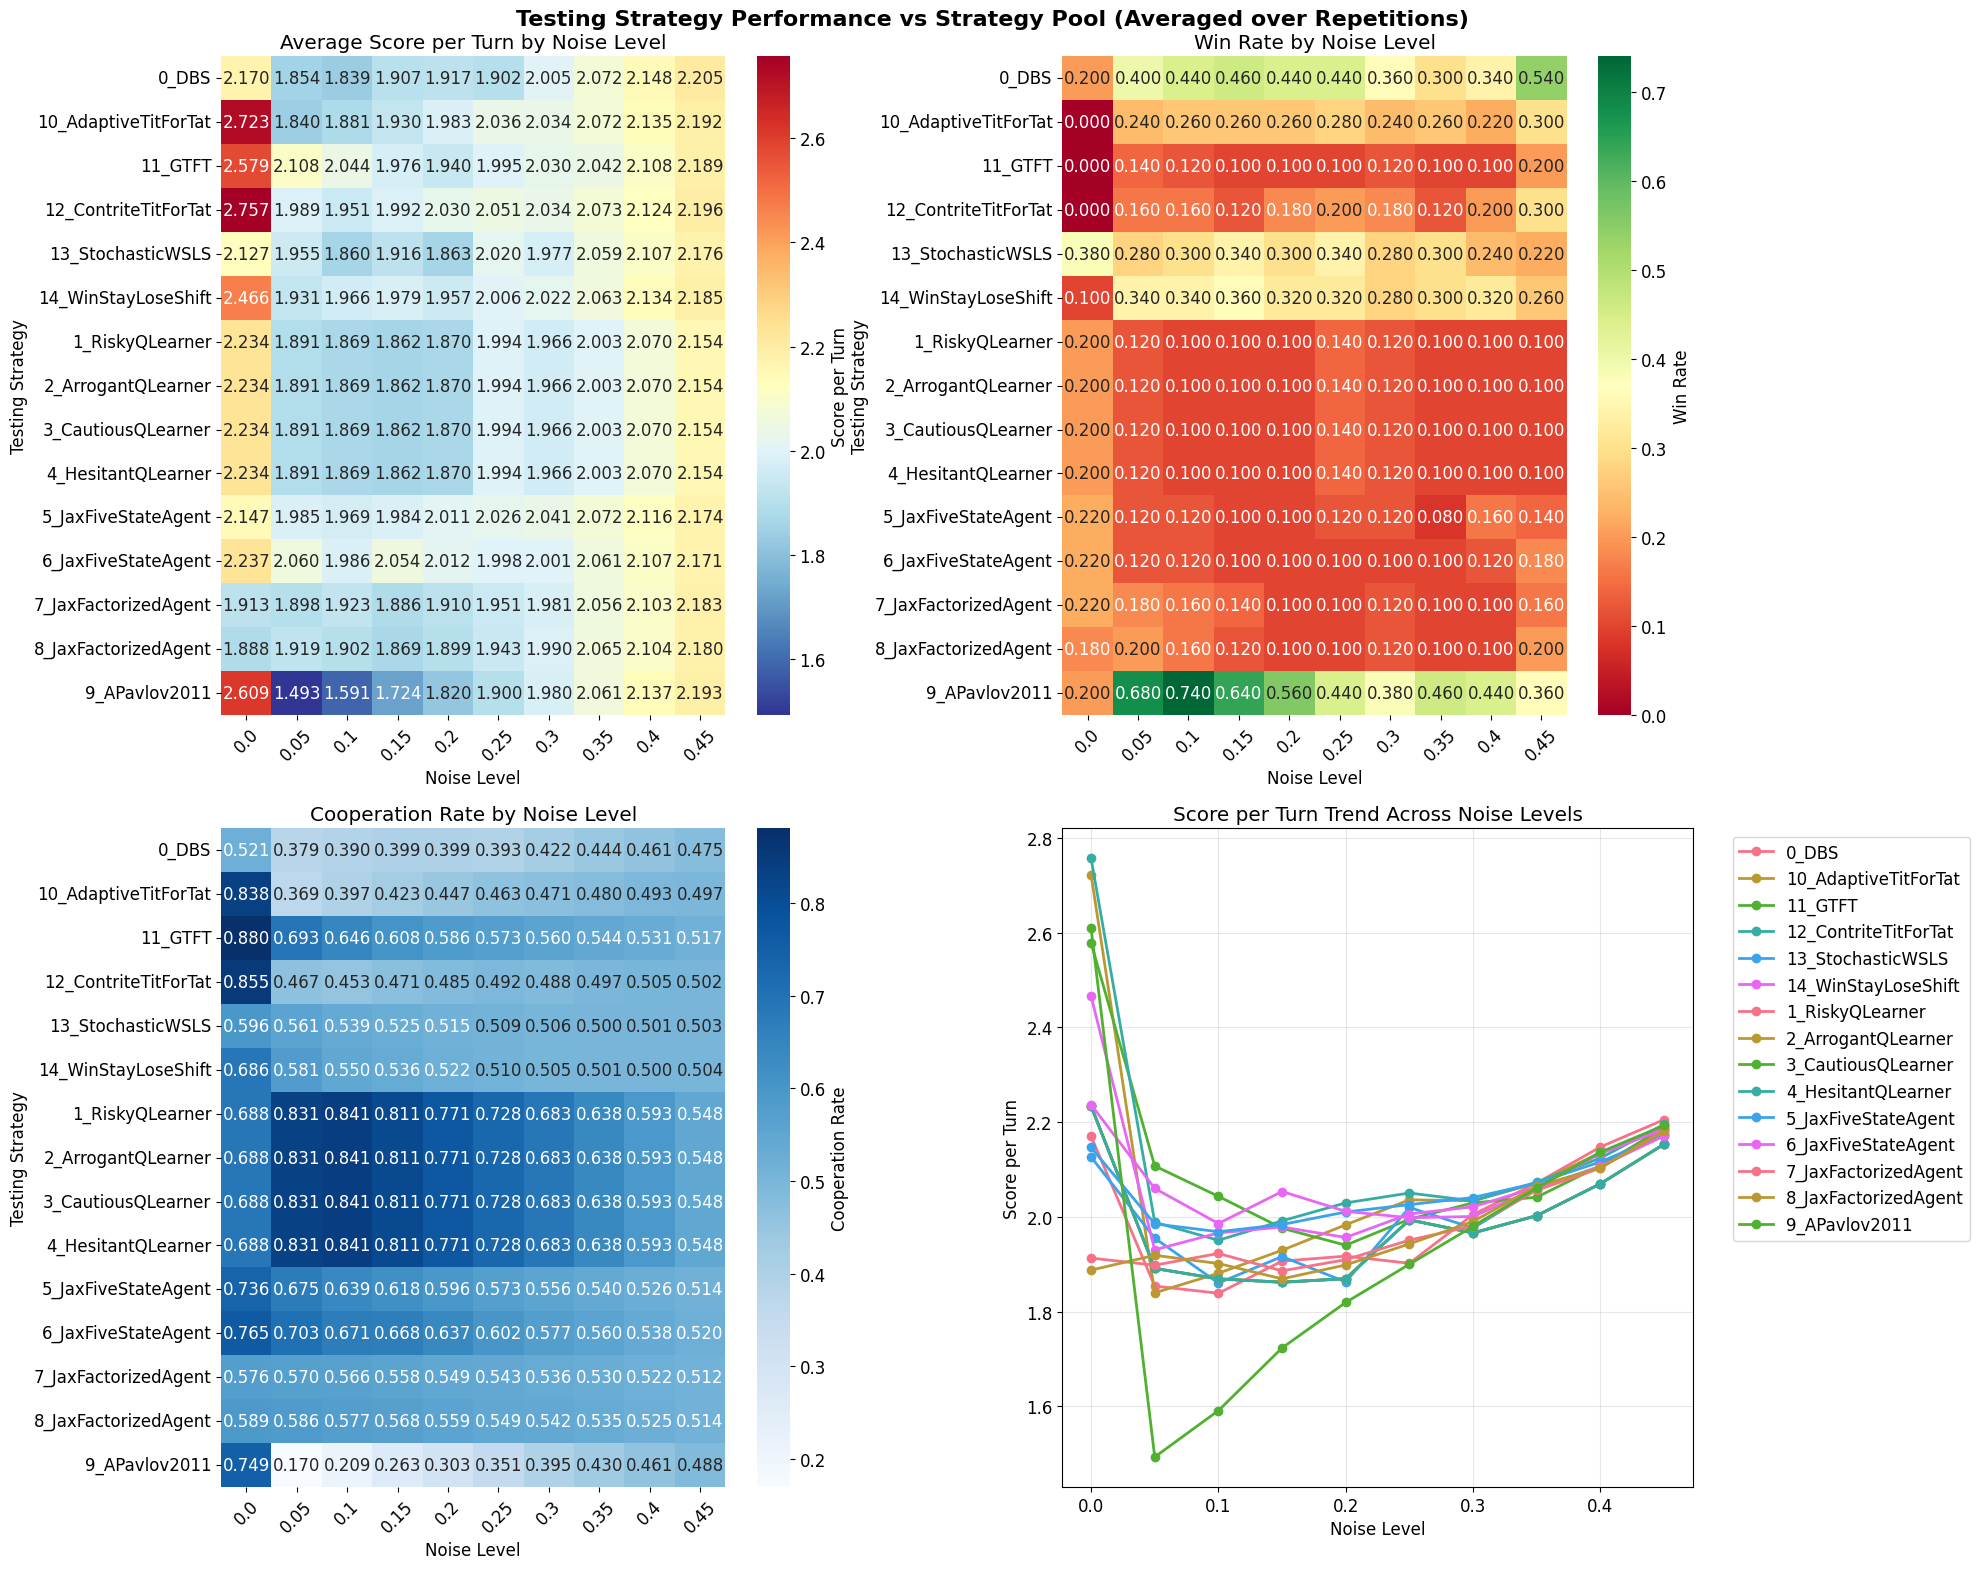

In [6]:
# Plot average scores across all noise levels
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Testing Strategy Performance vs Strategy Pool (Averaged over Repetitions)', fontsize=16, fontweight='bold')

# 1. Score per turn by noise level
ax1 = axes[0, 0]
pivot_data = avg_scores_overall.pivot(index='testing_strategy', columns='noise_level', values='Score per turn')
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlBu_r', ax=ax1, cbar_kws={'label': 'Score per Turn'})
ax1.set_title('Average Score per Turn by Noise Level')
ax1.set_xlabel('Noise Level')
ax1.set_ylabel('Testing Strategy')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)

# 2. Win rate by noise level
ax2 = axes[0, 1]
pivot_data = avg_scores_overall.pivot(index='testing_strategy', columns='noise_level', values='Win')
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax2, cbar_kws={'label': 'Win Rate'})
ax2.set_title('Win Rate by Noise Level')
ax2.set_xlabel('Noise Level')
ax2.set_ylabel('Testing Strategy')
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

# 3. Cooperation rate by noise level
ax3 = axes[1, 0]
pivot_data = avg_scores_overall.pivot(index='testing_strategy', columns='noise_level', values='Cooperation count')
# Normalize to cooperation rate (assuming 1500 turns)
pivot_data = pivot_data / 1500
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='Blues', ax=ax3, cbar_kws={'label': 'Cooperation Rate'})
ax3.set_title('Cooperation Rate by Noise Level')
ax3.set_xlabel('Noise Level')
ax3.set_ylabel('Testing Strategy')
ax3.tick_params(axis='x', rotation=45)
ax3.tick_params(axis='y', rotation=0)

# 4. Score per turn trend across noise levels
ax4 = axes[1, 1]
for strategy in avg_scores_overall['testing_strategy'].unique():
    strategy_data = avg_scores_overall[avg_scores_overall['testing_strategy'] == strategy]
    ax4.plot(strategy_data['noise_level'], strategy_data['Score per turn'], 
             marker='o', label=strategy, linewidth=2, markersize=6)

ax4.set_title('Score per Turn Trend Across Noise Levels')
ax4.set_xlabel('Noise Level')
ax4.set_ylabel('Score per Turn')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [18]:
pivot_data = avg_scores_overall.pivot(index='testing_strategy', columns='noise_level', values='Score per turn').to_latex()
print(pivot_data)

\begin{tabular}{lrrrrrrrrrr}
\toprule
noise_level & 0.000000 & 0.050000 & 0.100000 & 0.150000 & 0.200000 & 0.250000 & 0.300000 & 0.350000 & 0.400000 & 0.450000 \\
testing_strategy &  &  &  &  &  &  &  &  &  &  \\
\midrule
0_DBS & 2.170480 & 1.854213 & 1.838947 & 1.906787 & 1.917360 & 1.902293 & 2.005147 & 2.071667 & 2.147760 & 2.205453 \\
10_AdaptiveTitForTat & 2.722720 & 1.839893 & 1.881173 & 1.929733 & 1.983467 & 2.036240 & 2.034213 & 2.071560 & 2.135413 & 2.192213 \\
11_GTFT & 2.578893 & 2.107653 & 2.043587 & 1.976267 & 1.940413 & 1.995373 & 2.029760 & 2.041707 & 2.108307 & 2.188533 \\
12_ContriteTitForTat & 2.757187 & 1.988840 & 1.950827 & 1.991827 & 2.029747 & 2.050547 & 2.033920 & 2.073347 & 2.124253 & 2.195653 \\
13_StochasticWSLS & 2.126507 & 1.955253 & 1.860480 & 1.916467 & 1.862813 & 2.020093 & 1.976627 & 2.058947 & 2.106547 & 2.175960 \\
14_WinStayLoseShift & 2.465973 & 1.930667 & 1.966347 & 1.978840 & 1.956760 & 2.006320 & 2.021507 & 2.062507 & 2.133667 & 2.185467 \\
1_Risk

In [20]:
pivot_data = avg_scores_overall.pivot(index='testing_strategy', columns='noise_level', values='Cooperation count') / 1500
print(pivot_data.to_latex())

\begin{tabular}{lrrrrrrrrrr}
\toprule
noise_level & 0.000000 & 0.050000 & 0.100000 & 0.150000 & 0.200000 & 0.250000 & 0.300000 & 0.350000 & 0.400000 & 0.450000 \\
testing_strategy &  &  &  &  &  &  &  &  &  &  \\
\midrule
0_DBS & 0.521067 & 0.379413 & 0.390027 & 0.399240 & 0.398747 & 0.393373 & 0.422133 & 0.444173 & 0.460507 & 0.475493 \\
10_AdaptiveTitForTat & 0.838253 & 0.369387 & 0.397373 & 0.422733 & 0.446840 & 0.463133 & 0.470667 & 0.480253 & 0.493253 & 0.496827 \\
11_GTFT & 0.880453 & 0.692800 & 0.646467 & 0.607840 & 0.586160 & 0.573067 & 0.559773 & 0.544320 & 0.531307 & 0.516680 \\
12_ContriteTitForTat & 0.855320 & 0.466533 & 0.453107 & 0.471253 & 0.484667 & 0.491907 & 0.488013 & 0.496507 & 0.504640 & 0.501653 \\
13_StochasticWSLS & 0.596107 & 0.561000 & 0.538573 & 0.525227 & 0.515493 & 0.508613 & 0.505560 & 0.500387 & 0.500707 & 0.502707 \\
14_WinStayLoseShift & 0.686453 & 0.580933 & 0.549853 & 0.535840 & 0.521987 & 0.509747 & 0.505147 & 0.500760 & 0.500427 & 0.503707 \\
1_Risk

## Self-Cooperation Analysis

Let's analyze how each strategy performs when playing against itself (self-play).


In [8]:
def analyze_self_cooperation():
    """
    Analyze self-cooperation rates - how each strategy performs against itself
    """
    # Filter for self-play games (Player index 0 vs Opponent index 0)
    # This means the testing strategy is playing against itself
    self_play_data = tournament_data[
        (tournament_data['Player index'] == 0) & 
        (tournament_data['Opponent index'] == 0)
    ].copy()
    
    print(f"Found {len(self_play_data)} self-play interactions")
    
    # Calculate self-cooperation metrics
    self_cooperation_stats = self_play_data.groupby(['testing_strategy', 'noise_level']).agg({
        'Score per turn': 'mean',
        'Win': 'mean',  # This should be ~0.5 for self-play
        'Cooperation count': 'mean',
        'Turns': 'mean',
        'CC count': 'mean',
        'CD count': 'mean', 
        'DC count': 'mean',
        'DD count': 'mean'
    }).reset_index()
    
    # Calculate cooperation rate
    self_cooperation_stats['Cooperation rate'] = self_cooperation_stats['Cooperation count'] / self_cooperation_stats['Turns']
    
    # Calculate mutual cooperation rate (CC / Total turns)
    self_cooperation_stats['Mutual cooperation rate'] = self_cooperation_stats['CC count'] / self_cooperation_stats['Turns']
    
    # Calculate mutual defection rate (DD / Total turns) 
    self_cooperation_stats['Mutual defection rate'] = self_cooperation_stats['DD count'] / self_cooperation_stats['Turns']
    
    # Calculate exploitation rate (CD + DC) / Total turns
    self_cooperation_stats['Exploitation rate'] = (self_cooperation_stats['CD count'] + self_cooperation_stats['DC count']) / self_cooperation_stats['Turns']
    
    return self_cooperation_stats

# Calculate self-cooperation statistics
self_coop_stats = analyze_self_cooperation()

print("\nSelf-cooperation statistics calculated!")
print(f"Shape: {self_coop_stats.shape}")
print(f"Strategies analyzed: {self_coop_stats['testing_strategy'].nunique()}")
print(f"Noise levels: {sorted(self_coop_stats['noise_level'].unique())}")


Found 1500 self-play interactions

Self-cooperation statistics calculated!
Shape: (150, 14)
Strategies analyzed: 15
Noise levels: [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45)]


In [9]:
# Create self-cooperation summary table
print("=" * 80)
print("SELF-COOPERATION RATES BY STRATEGY")
print("=" * 80)

# Average across all noise levels for overall ranking
overall_self_coop = self_coop_stats.groupby('testing_strategy').agg({
    'Score per turn': 'mean',
    'Cooperation rate': 'mean',
    'Mutual cooperation rate': 'mean',
    'Mutual defection rate': 'mean',
    'Exploitation rate': 'mean'
}).round(4)

# Sort by mutual cooperation rate (descending)
overall_self_coop = overall_self_coop.sort_values('Mutual cooperation rate', ascending=False)
overall_self_coop['Rank'] = range(1, len(overall_self_coop) + 1)

print("\nOVERALL SELF-COOPERATION RANKING (Averaged across all noise levels):")
print("-" * 80)
display_cols = ['Rank', 'Score per turn', 'Cooperation rate', 'Mutual cooperation rate', 
                'Mutual defection rate', 'Exploitation rate']
print(overall_self_coop[display_cols].to_string())

# Show Active Inference agents specifically
print("\n" + "=" * 80)
print("ACTIVE INFERENCE AGENTS - SELF-COOPERATION")
print("=" * 80)
aif_agents = ['5_JaxFiveStateAgent', '6_JaxFiveStateAgent', '7_JaxFactorizedAgent', '8_JaxFactorizedAgent']
aif_self_coop = overall_self_coop.loc[aif_agents]
print(aif_self_coop[display_cols].to_string())

print(f"\nActive Inference agents ranked by mutual cooperation rate:")
for i, (agent, row) in enumerate(aif_self_coop.iterrows(), 1):
    print(f"{i}. {agent}: {row['Mutual cooperation rate']:.3f} mutual cooperation rate")
    print(f"   Score per turn: {row['Score per turn']:.3f}, Overall rank: {int(row['Rank'])}/15")


SELF-COOPERATION RATES BY STRATEGY

OVERALL SELF-COOPERATION RANKING (Averaged across all noise levels):
--------------------------------------------------------------------------------
                      Rank  Score per turn  Cooperation rate  Mutual cooperation rate  Mutual defection rate  Exploitation rate
testing_strategy                                                                                                               
1_RiskyQLearner          1          2.6684            0.7471                   0.5730                 0.0788             0.3482
3_CautiousQLearner       2          2.6684            0.7471                   0.5730                 0.0788             0.3482
2_ArrogantQLearner       3          2.6684            0.7471                   0.5730                 0.0788             0.3482
4_HesitantQLearner       4          2.6684            0.7471                   0.5730                 0.0788             0.3482
11_GTFT                  5          2.5733    

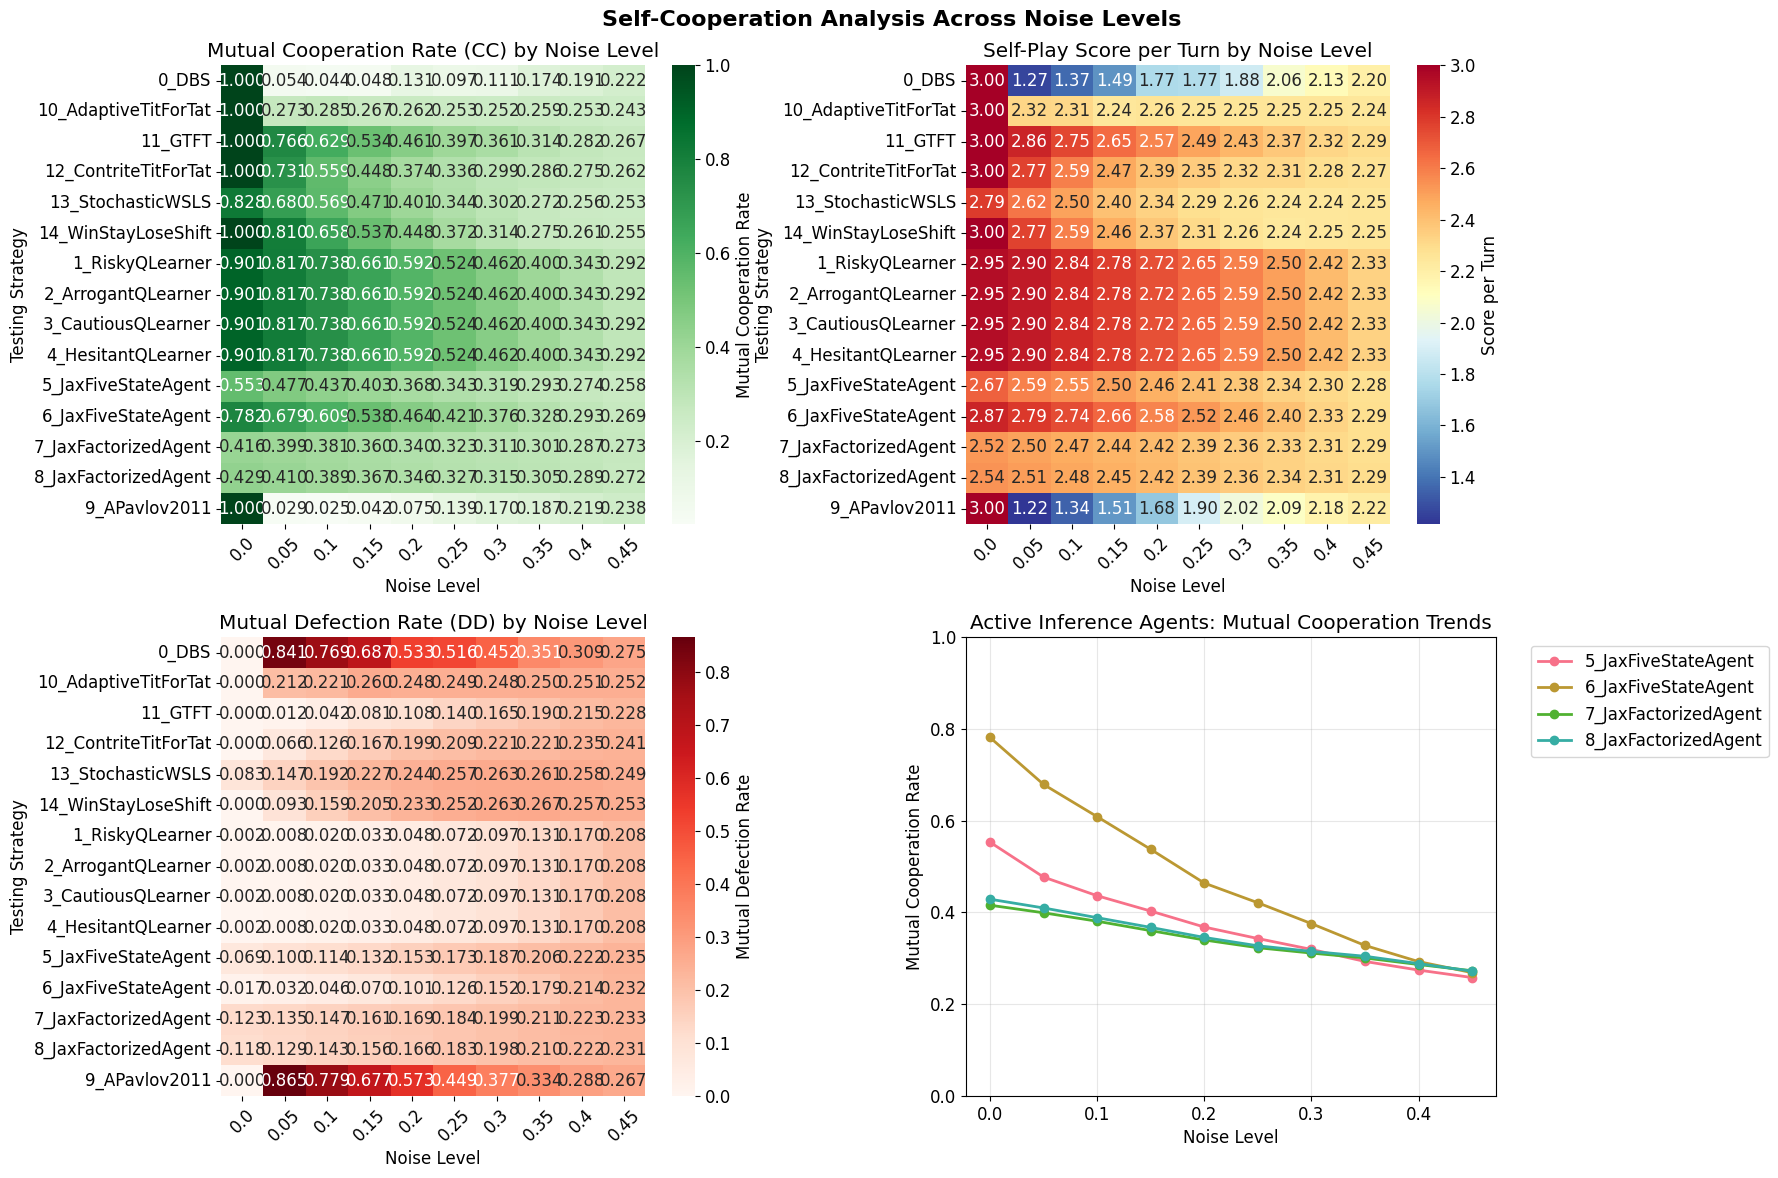

In [10]:
# Visualize self-cooperation across noise levels
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Self-Cooperation Analysis Across Noise Levels', fontsize=16, fontweight='bold')

# 1. Mutual cooperation rate by noise level
ax1 = axes[0, 0]
pivot_data = self_coop_stats.pivot(index='testing_strategy', columns='noise_level', values='Mutual cooperation rate')
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='Greens', ax=ax1, 
            cbar_kws={'label': 'Mutual Cooperation Rate'})
ax1.set_title('Mutual Cooperation Rate (CC) by Noise Level')
ax1.set_xlabel('Noise Level')
ax1.set_ylabel('Testing Strategy')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)

# 2. Score per turn in self-play
ax2 = axes[0, 1]
pivot_data = self_coop_stats.pivot(index='testing_strategy', columns='noise_level', values='Score per turn')
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='RdYlBu_r', ax=ax2,
            cbar_kws={'label': 'Score per Turn'})
ax2.set_title('Self-Play Score per Turn by Noise Level')
ax2.set_xlabel('Noise Level')
ax2.set_ylabel('Testing Strategy')
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

# 3. Mutual defection rate
ax3 = axes[1, 0]
pivot_data = self_coop_stats.pivot(index='testing_strategy', columns='noise_level', values='Mutual defection rate')
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='Reds', ax=ax3,
            cbar_kws={'label': 'Mutual Defection Rate'})
ax3.set_title('Mutual Defection Rate (DD) by Noise Level')
ax3.set_xlabel('Noise Level')
ax3.set_ylabel('Testing Strategy')
ax3.tick_params(axis='x', rotation=45)
ax3.tick_params(axis='y', rotation=0)

# 4. Trends for Active Inference agents
ax4 = axes[1, 1]
aif_agents = ['5_JaxFiveStateAgent', '6_JaxFiveStateAgent', '7_JaxFactorizedAgent', '8_JaxFactorizedAgent']
for agent in aif_agents:
    agent_data = self_coop_stats[self_coop_stats['testing_strategy'] == agent]
    ax4.plot(agent_data['noise_level'], agent_data['Mutual cooperation rate'], 
             marker='o', label=agent, linewidth=2, markersize=6)

ax4.set_title('Active Inference Agents: Mutual Cooperation Trends')
ax4.set_xlabel('Noise Level')
ax4.set_ylabel('Mutual Cooperation Rate')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 1)

plt.tight_layout()
plt.show()


## Export Results to CSV Files

Save all processed DataFrames to CSV files in the final directory for future analysis.


In [11]:
# Create analysis_results directory within final/
analysis_dir = final_dir / 'analysis_results'
analysis_dir.mkdir(exist_ok=True)

print("Exporting processed data to CSV files...")
print(f"Export directory: {analysis_dir}")

# 1. Export raw tournament data (full dataset)
print("\n1. Exporting full tournament dataset...")
tournament_data.to_csv(analysis_dir / 'full_tournament_data.csv', index=False)
print(f"   ✓ Saved: full_tournament_data.csv ({len(tournament_data)} rows)")

# 2. Export overall average scores
print("\n2. Exporting overall average scores...")
avg_scores_overall.to_csv(analysis_dir / 'overall_average_scores.csv', index=False)
print(f"   ✓ Saved: overall_average_scores.csv ({len(avg_scores_overall)} rows)")

# 3. Export detailed average scores (by opponent)
print("\n3. Exporting detailed average scores...")
avg_scores_detailed.to_csv(analysis_dir / 'detailed_average_scores.csv', index=False)
print(f"   ✓ Saved: detailed_average_scores.csv ({len(avg_scores_detailed)} rows)")

# 4. Export rankings
print("\n4. Exporting strategy rankings...")
# rankings.to_csv(analysis_dir / 'strategy_rankings.csv')
# print(f"   ✓ Saved: strategy_rankings.csv ({len(rankings)} strategies)")

# 5. Export crossplay matrices for each noise level
print("\n5. Exporting crossplay matrices by noise level...")
for noise in noise_levels:
    # Filter data for this noise level
    data_noise = avg_scores_detailed[avg_scores_detailed['noise_level'] == noise]
    
    # Create pivot table for crossplay matrix
    crossplay_matrix = data_noise.pivot_table(
        index='testing_strategy',
        columns='opponent_name_clean',
        values='Score per turn',
        aggfunc='mean'
    )
    
    # Save to CSV
    filename = f'crossplay_matrix_noise_{noise}.csv'
    crossplay_matrix.to_csv(analysis_dir / filename)
    print(f"   ✓ Saved: {filename} ({crossplay_matrix.shape[0]}x{crossplay_matrix.shape[1]})")

# 6. Export summary statistics by noise level
print("\n6. Exporting summary statistics by noise level...")
noise_summaries = []
for noise in noise_levels:
    noise_data = avg_scores_overall[avg_scores_overall['noise_level'] == noise]
    summary = {
        'noise_level': noise,
        'mean_score_per_turn': noise_data['Score per turn'].mean(),
        'std_score_per_turn': noise_data['Score per turn'].std(),
        'mean_win_rate': noise_data['Win'].mean(),
        'std_win_rate': noise_data['Win'].std(),
        'mean_cooperation_count': noise_data['Cooperation count'].mean(),
        'std_cooperation_count': noise_data['Cooperation count'].std(),
        'best_strategy': noise_data.loc[noise_data['Score per turn'].idxmax(), 'testing_strategy'],
        'best_score': noise_data['Score per turn'].max(),
        'worst_strategy': noise_data.loc[noise_data['Score per turn'].idxmin(), 'testing_strategy'],
        'worst_score': noise_data['Score per turn'].min()
    }
    noise_summaries.append(summary)

noise_summary_df = pd.DataFrame(noise_summaries)
noise_summary_df.to_csv(analysis_dir / 'noise_level_summaries.csv', index=False)
print(f"   ✓ Saved: noise_level_summaries.csv ({len(noise_summary_df)} noise levels)")

# 7. Export strategy performance across noise levels
print("\n7. Exporting strategy performance across noise levels...")
strategy_noise_performance = avg_scores_overall.pivot_table(
    index='testing_strategy',
    columns='noise_level',
    values=['Score per turn', 'Win', 'Cooperation count'],
    aggfunc='mean'
)

# Flatten column names
strategy_noise_performance.columns = [f"{col[0]}_noise_{col[1]}" for col in strategy_noise_performance.columns]
strategy_noise_performance.to_csv(analysis_dir / 'strategy_performance_by_noise.csv')
print(f"   ✓ Saved: strategy_performance_by_noise.csv ({len(strategy_noise_performance)} strategies)")

print("\n" + "="*60)
print("MAIN EXPORT COMPLETE!")
print("="*60)
print(f"All files saved to: {analysis_dir}")
print(f"Total files exported: 7 + {len(noise_levels)} crossplay matrices = {7 + len(noise_levels)} files")

# Display directory contents
print(f"\nContents of {analysis_dir}:")
for file in sorted(analysis_dir.glob('*.csv')):
    file_size = file.stat().st_size / 1024  # KB
    print(f"  📄 {file.name} ({file_size:.1f} KB)")

print(f"\n🎉 Main analysis complete! You can now use these CSV files for further analysis or sharing results.")


Exporting processed data to CSV files...
Export directory: final_2/analysis_results

1. Exporting full tournament dataset...
   ✓ Saved: full_tournament_data.csv (67500 rows)

2. Exporting overall average scores...
   ✓ Saved: overall_average_scores.csv (150 rows)

3. Exporting detailed average scores...
   ✓ Saved: detailed_average_scores.csv (1350 rows)

4. Exporting strategy rankings...

5. Exporting crossplay matrices by noise level...
   ✓ Saved: crossplay_matrix_noise_0.0.csv (15x21)
   ✓ Saved: crossplay_matrix_noise_0.05.csv (15x21)
   ✓ Saved: crossplay_matrix_noise_0.1.csv (15x21)
   ✓ Saved: crossplay_matrix_noise_0.15.csv (15x21)
   ✓ Saved: crossplay_matrix_noise_0.2.csv (15x21)
   ✓ Saved: crossplay_matrix_noise_0.25.csv (15x21)
   ✓ Saved: crossplay_matrix_noise_0.3.csv (15x21)
   ✓ Saved: crossplay_matrix_noise_0.35.csv (15x21)
   ✓ Saved: crossplay_matrix_noise_0.4.csv (15x21)
   ✓ Saved: crossplay_matrix_noise_0.45.csv (15x21)

6. Exporting summary statistics by noise

## Mutual Cooperation Analysis

Let's analyze the mutual cooperation rates for each strategy across all opponents (how often both players cooperated after noise).


In [12]:
def analyze_mutual_cooperation():
    """
    Analyze mutual cooperation rates for each strategy across all opponents
    """
    # Filter for testing strategy performance (Player index = 0)
    testing_performance = tournament_data[tournament_data['Player index'] == 0].copy()
    
    print(f"Analyzing mutual cooperation for {len(testing_performance)} interactions")
    
    # Calculate mutual cooperation metrics
    mutual_coop_stats = testing_performance.groupby(['testing_strategy', 'noise_level']).agg({
        'Score per turn': 'mean',
        'Win': 'mean',
        'Cooperation count': 'mean',
        'Turns': 'mean',
        'CC count': 'mean',  # Mutual cooperation count
        'CD count': 'mean',  # Testing strategy cooperates, opponent defects
        'DC count': 'mean',  # Testing strategy defects, opponent cooperates  
        'DD count': 'mean'   # Mutual defection count
    }).reset_index()
    
    # Calculate rates
    mutual_coop_stats['Mutual cooperation rate'] = mutual_coop_stats['CC count'] / mutual_coop_stats['Turns']
    mutual_coop_stats['Mutual defection rate'] = mutual_coop_stats['DD count'] / mutual_coop_stats['Turns']
    mutual_coop_stats['Exploitation rate'] = (mutual_coop_stats['CD count'] + mutual_coop_stats['DC count']) / mutual_coop_stats['Turns']
    mutual_coop_stats['Individual cooperation rate'] = mutual_coop_stats['Cooperation count'] / mutual_coop_stats['Turns']
    
    # Calculate opponent cooperation rate (CC + DC) / Total turns
    mutual_coop_stats['Opponent cooperation rate'] = (mutual_coop_stats['CC count'] + mutual_coop_stats['DC count']) / mutual_coop_stats['Turns']
    
    return mutual_coop_stats

# Calculate mutual cooperation statistics
mutual_coop_stats = analyze_mutual_cooperation()

print("\nMutual cooperation statistics calculated!")
print(f"Shape: {mutual_coop_stats.shape}")
print(f"Strategies analyzed: {mutual_coop_stats['testing_strategy'].nunique()}")
print(f"Noise levels: {sorted(mutual_coop_stats['noise_level'].unique())}")


Analyzing mutual cooperation for 7500 interactions

Mutual cooperation statistics calculated!
Shape: (150, 15)
Strategies analyzed: 15
Noise levels: [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45)]


In [13]:
# Create mutual cooperation summary table BY NOISE LEVEL
print("=" * 80)
print("MUTUAL COOPERATION RATES BY STRATEGY AND NOISE LEVEL (Against All Opponents)")
print("=" * 80)

# Show results for each noise level separately
aif_agents = ['5_JaxFiveStateAgent', '6_JaxFiveStateAgent', '7_JaxFactorizedAgent', '8_JaxFactorizedAgent']

for noise in sorted(mutual_coop_stats['noise_level'].unique()):
    print(f"\n{'='*60}")
    print(f"NOISE LEVEL: {noise}")
    print(f"{'='*60}")
    
    # Filter data for this noise level
    noise_data = mutual_coop_stats[mutual_coop_stats['noise_level'] == noise].copy()
    
    # Sort by mutual cooperation rate (descending)
    noise_data = noise_data.sort_values('Mutual cooperation rate', ascending=False)
    noise_data['Rank'] = range(1, len(noise_data) + 1)
    
    print(f"\nAll Strategies at Noise Level {noise}:")
    print("-" * 50)
    display_cols = ['Rank', 'testing_strategy', 'Score per turn', 'Mutual cooperation rate', 
                    'Individual cooperation rate', 'Opponent cooperation rate']
    print(noise_data[display_cols].round(4).to_string(index=False))
    
    # Show Active Inference agents specifically for this noise level
    print(f"\nActive Inference Agents at Noise Level {noise}:")
    print("-" * 45)
    aif_noise_data = noise_data[noise_data['testing_strategy'].isin(aif_agents)]
    if not aif_noise_data.empty:
        for _, row in aif_noise_data.iterrows():
            print(f"• {row['testing_strategy']}: Rank {int(row['Rank'])}/15")
            print(f"  Mutual cooperation: {row['Mutual cooperation rate']:.3f}")
            print(f"  Individual cooperation: {row['Individual cooperation rate']:.3f}")
            print(f"  Opponent cooperation: {row['Opponent cooperation rate']:.3f}")
            print(f"  Score per turn: {row['Score per turn']:.3f}")
            print()
    
    # Show top 3 strategies for this noise level
    top_3 = noise_data.head(3)
    print(f"Top 3 Strategies at Noise Level {noise}:")
    print("-" * 35)
    for i, (_, row) in enumerate(top_3.iterrows(), 1):
        print(f"{i}. {row['testing_strategy']}: {row['Mutual cooperation rate']:.3f} mutual cooperation")

# Summary comparison across noise levels
print(f"\n{'='*80}")
print("SUMMARY: ACTIVE INFERENCE AGENTS ACROSS NOISE LEVELS")
print(f"{'='*80}")

for agent in aif_agents:
    agent_data = mutual_coop_stats[mutual_coop_stats['testing_strategy'] == agent]
    print(f"\n{agent}:")
    print("-" * len(agent))
    for _, row in agent_data.iterrows():
        print(f"  Noise {row['noise_level']:.2f}: {row['Mutual cooperation rate']:.3f} mutual cooperation")
    
    # Show trend
    best_noise = agent_data.loc[agent_data['Mutual cooperation rate'].idxmax(), 'noise_level']
    worst_noise = agent_data.loc[agent_data['Mutual cooperation rate'].idxmin(), 'noise_level']
    print(f"  Best at noise {best_noise:.2f}, Worst at noise {worst_noise:.2f}")
    print(f"  Range: {agent_data['Mutual cooperation rate'].min():.3f} - {agent_data['Mutual cooperation rate'].max():.3f}")


MUTUAL COOPERATION RATES BY STRATEGY AND NOISE LEVEL (Against All Opponents)

NOISE LEVEL: 0.0

All Strategies at Noise Level 0.0:
--------------------------------------------------
 Rank     testing_strategy  Score per turn  Mutual cooperation rate  Individual cooperation rate  Opponent cooperation rate
    1              11_GTFT          2.5789                   0.8169                       0.8805                     0.8191
    2 12_ContriteTitForTat          2.7572                   0.8084                       0.8553                     0.8552
    3 10_AdaptiveTitForTat          2.7227                   0.7895                       0.8383                     0.8376
    4        9_APavlov2011          2.6094                   0.7445                       0.7492                     0.7758
    5  6_JaxFiveStateAgent          2.2369                   0.6217                       0.7647                     0.6558
    6      1_RiskyQLearner          2.2342                   0.5973       

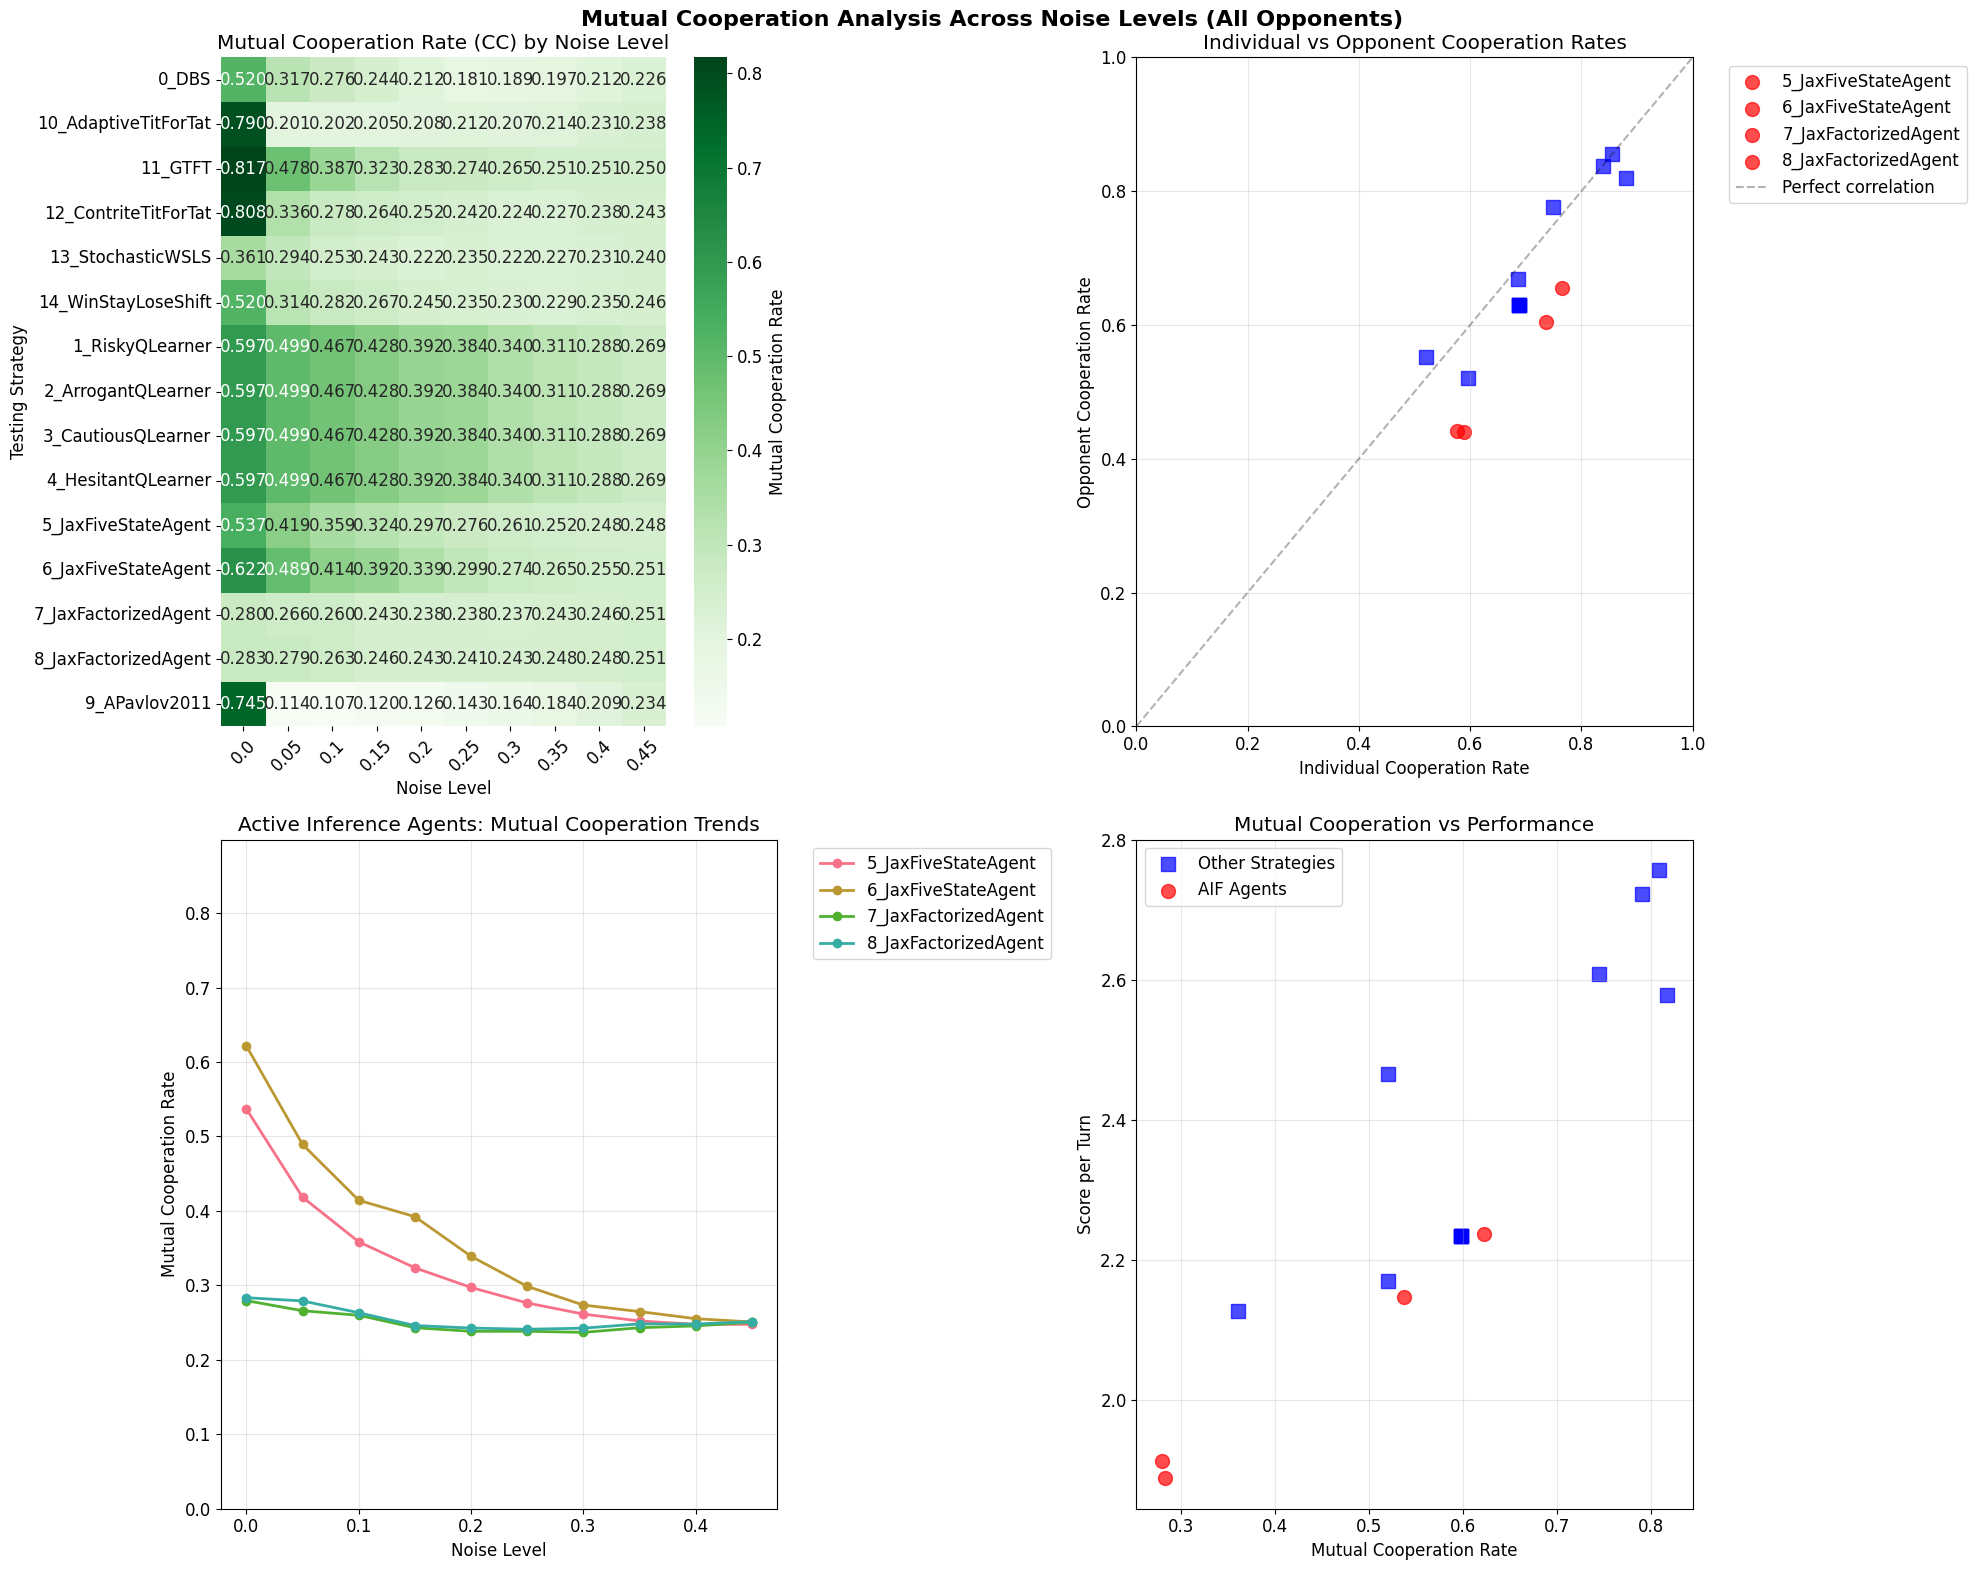

In [14]:
# Visualize mutual cooperation across noise levels
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Mutual Cooperation Analysis Across Noise Levels (All Opponents)', fontsize=16, fontweight='bold')

# 1. Mutual cooperation rate by noise level
ax1 = axes[0, 0]
pivot_data = mutual_coop_stats.pivot(index='testing_strategy', columns='noise_level', values='Mutual cooperation rate')
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='Greens', ax=ax1, 
            cbar_kws={'label': 'Mutual Cooperation Rate'})
ax1.set_title('Mutual Cooperation Rate (CC) by Noise Level')
ax1.set_xlabel('Noise Level')
ax1.set_ylabel('Testing Strategy')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)

# 2. Individual vs Opponent cooperation rates (using noise level 0.0 as example)
ax2 = axes[0, 1]
noise_0_data = mutual_coop_stats[mutual_coop_stats['noise_level'] == 0.0]
# Create a scatter plot comparing individual vs opponent cooperation rates
for _, row in noise_0_data.iterrows():
    strategy = row['testing_strategy']
    color = 'red' if strategy in aif_agents else 'blue'
    marker = 'o' if strategy in aif_agents else 's'
    ax2.scatter(row['Individual cooperation rate'], 
               row['Opponent cooperation rate'],
               c=color, marker=marker, s=100, alpha=0.7, label=strategy if strategy in aif_agents else "")

ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect correlation')
ax2.set_xlabel('Individual Cooperation Rate')
ax2.set_ylabel('Opponent Cooperation Rate')
ax2.set_title('Individual vs Opponent Cooperation Rates')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

# 3. Mutual cooperation trends for Active Inference agents
ax3 = axes[1, 0]
for agent in aif_agents:
    agent_data = mutual_coop_stats[mutual_coop_stats['testing_strategy'] == agent]
    ax3.plot(agent_data['noise_level'], agent_data['Mutual cooperation rate'], 
             marker='o', label=agent, linewidth=2, markersize=6)

ax3.set_title('Active Inference Agents: Mutual Cooperation Trends')
ax3.set_xlabel('Noise Level')
ax3.set_ylabel('Mutual Cooperation Rate')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, max(mutual_coop_stats['Mutual cooperation rate']) * 1.1)

# 4. Score vs Mutual Cooperation correlation (using noise level 0.0 as example)
ax4 = axes[1, 1]
for _, row in noise_0_data.iterrows():
    strategy = row['testing_strategy']
    color = 'red' if strategy in aif_agents else 'blue'
    marker = 'o' if strategy in aif_agents else 's'
    ax4.scatter(row['Mutual cooperation rate'], 
               row['Score per turn'],
               c=color, marker=marker, s=100, alpha=0.7, 
               label='AIF Agents' if strategy in aif_agents and strategy == aif_agents[0] else 
                     'Other Strategies' if strategy not in aif_agents and row.name == noise_0_data.index[0] else "")

ax4.set_xlabel('Mutual Cooperation Rate')
ax4.set_ylabel('Score per Turn')
ax4.set_title('Mutual Cooperation vs Performance')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
# Export mutual cooperation data to CSV files
print("\n" + "="*60)
print("EXPORTING MUTUAL COOPERATION DATA")
print("="*60)

# Define analysis directory (same as main export section)
analysis_dir = final_dir / 'analysis_results'
analysis_dir.mkdir(exist_ok=True)

# Export mutual cooperation statistics
print("📊 Mutual Cooperation Data:")
mutual_coop_stats.to_csv(analysis_dir / 'mutual_cooperation_detailed.csv', index=False)
print(f"✓ Saved: mutual_cooperation_detailed.csv ({len(mutual_coop_stats)} rows)")
print(f"  Contains: Mutual cooperation stats for all strategies across all noise levels")

# Create summary table for export (by noise level, not averaged)
mutual_coop_summary = mutual_coop_stats[['testing_strategy', 'noise_level', 'Mutual cooperation rate', 
                                        'Score per turn', 'Individual cooperation rate', 'Opponent cooperation rate']].copy()
mutual_coop_summary.to_csv(analysis_dir / 'mutual_cooperation_summary.csv', index=False)
print(f"✓ Saved: mutual_cooperation_summary.csv ({len(mutual_coop_summary)} rows)")
print(f"  Contains: Mutual cooperation stats by strategy and noise level (not averaged)")

# Export mutual cooperation pivot table by noise level
print(f"\nExporting mutual cooperation pivot tables...")
mutual_coop_pivot = mutual_coop_stats.pivot_table(
    index='testing_strategy',
    columns='noise_level',
    values=['Mutual cooperation rate', 'Score per turn', 'Individual cooperation rate', 'Opponent cooperation rate'],
    aggfunc='mean'
)

# Flatten column names
mutual_coop_pivot.columns = [f"{col[0]}_noise_{col[1]}" for col in mutual_coop_pivot.columns]
mutual_coop_pivot.to_csv(analysis_dir / 'mutual_cooperation_by_noise.csv')
print(f"✓ Saved: mutual_cooperation_by_noise.csv ({len(mutual_coop_pivot)} strategies)")
print(f"  Contains: Mutual cooperation metrics across noise levels in pivot format")

print(f"\n📊 Mutual cooperation analysis complete!")
print(f"Files saved to: {analysis_dir}")

# Display key mutual cooperation findings
print(f"\n" + "="*60)
print("KEY MUTUAL COOPERATION FINDINGS")
print("="*60)

# Show findings for noise level 0.0 as example
noise_0_data = mutual_coop_stats[mutual_coop_stats['noise_level'] == 0.0].sort_values('Mutual cooperation rate', ascending=False)
top_3_mutual = noise_0_data.head(3)
print(f"Top 3 strategies for mutual cooperation at noise level 0.0:")
for i, (_, row) in enumerate(top_3_mutual.iterrows(), 1):
    print(f"{i}. {row['testing_strategy']}: {row['Mutual cooperation rate']:.3f} mutual cooperation")

print(f"\nActive Inference agents mutual cooperation at noise level 0.0:")
aif_noise_0 = noise_0_data[noise_0_data['testing_strategy'].isin(aif_agents)]
for i, (_, row) in enumerate(aif_noise_0.iterrows(), 1):
    rank = noise_0_data.index.get_loc(row.name) + 1
    print(f"{i}. {row['testing_strategy']}: Rank {rank}/15 ({row['Mutual cooperation rate']:.3f} mutual cooperation)")

print(f"\n🎯 Mutual cooperation analysis complete! Check the CSV files for detailed data.")



EXPORTING MUTUAL COOPERATION DATA
📊 Mutual Cooperation Data:
✓ Saved: mutual_cooperation_detailed.csv (150 rows)
  Contains: Mutual cooperation stats for all strategies across all noise levels
✓ Saved: mutual_cooperation_summary.csv (150 rows)
  Contains: Mutual cooperation stats by strategy and noise level (not averaged)

Exporting mutual cooperation pivot tables...
✓ Saved: mutual_cooperation_by_noise.csv (15 strategies)
  Contains: Mutual cooperation metrics across noise levels in pivot format

📊 Mutual cooperation analysis complete!
Files saved to: final_2/analysis_results

KEY MUTUAL COOPERATION FINDINGS
Top 3 strategies for mutual cooperation at noise level 0.0:
1. 11_GTFT: 0.817 mutual cooperation
2. 12_ContriteTitForTat: 0.808 mutual cooperation
3. 10_AdaptiveTitForTat: 0.790 mutual cooperation

Active Inference agents mutual cooperation at noise level 0.0:
1. 6_JaxFiveStateAgent: Rank 5/15 (0.622 mutual cooperation)
2. 5_JaxFiveStateAgent: Rank 10/15 (0.537 mutual cooperation

In [16]:
# Export self-cooperation data to CSV files
print("\n" + "="*60)
print("EXPORTING SELF-COOPERATION DATA")
print("="*60)

# Define analysis directory (same as main export section)
analysis_dir = final_dir / 'analysis_results'
analysis_dir.mkdir(exist_ok=True)

# Export detailed self-cooperation statistics (all noise levels)
self_coop_stats.to_csv(analysis_dir / 'self_cooperation_detailed.csv', index=False)
print(f"✓ Saved: self_cooperation_detailed.csv ({len(self_coop_stats)} rows)")
print(f"  Contains: Self-cooperation stats for all strategies across all noise levels")

# Export summary self-cooperation statistics (averaged across noise levels)
overall_self_coop.to_csv(analysis_dir / 'self_cooperation_summary.csv')
print(f"✓ Saved: self_cooperation_summary.csv ({len(overall_self_coop)} strategies)")
print(f"  Contains: Overall self-cooperation rankings averaged across noise levels")

# Export self-cooperation pivot table by noise level
print(f"\nExporting self-cooperation pivot tables...")
self_coop_pivot = self_coop_stats.pivot_table(
    index='testing_strategy',
    columns='noise_level',
    values=['Mutual cooperation rate', 'Score per turn', 'Cooperation rate'],
    aggfunc='mean'
)

# Flatten column names
self_coop_pivot.columns = [f"{col[0]}_noise_{col[1]}" for col in self_coop_pivot.columns]
self_coop_pivot.to_csv(analysis_dir / 'self_cooperation_by_noise.csv')
print(f"✓ Saved: self_cooperation_by_noise.csv ({len(self_coop_pivot)} strategies)")
print(f"  Contains: Self-cooperation metrics across noise levels in pivot format")

print(f"\n📊 Self-cooperation analysis complete!")
print(f"Files saved to: {analysis_dir}")

# Display key findings
print(f"\n" + "="*60)
print("KEY SELF-COOPERATION FINDINGS")
print("="*60)

top_3_coop = overall_self_coop.head(3)
print(f"Top 3 most cooperative strategies (in self-play):")
for i, (strategy, row) in enumerate(top_3_coop.iterrows(), 1):
    print(f"{i}. {strategy}: {row['Mutual cooperation rate']:.3f} mutual cooperation")

print(f"\nActive Inference agents self-cooperation ranking:")
aif_ranking = overall_self_coop.loc[aif_agents]
for i, (agent, row) in enumerate(aif_ranking.iterrows(), 1):
    overall_rank = int(row['Rank'])
    print(f"{i}. {agent}: Rank {overall_rank}/15 ({row['Mutual cooperation rate']:.3f} mutual cooperation)")

print(f"\n🎯 Analysis complete! Check the CSV files for detailed data.")



EXPORTING SELF-COOPERATION DATA
✓ Saved: self_cooperation_detailed.csv (150 rows)
  Contains: Self-cooperation stats for all strategies across all noise levels
✓ Saved: self_cooperation_summary.csv (15 strategies)
  Contains: Overall self-cooperation rankings averaged across noise levels

Exporting self-cooperation pivot tables...
✓ Saved: self_cooperation_by_noise.csv (15 strategies)
  Contains: Self-cooperation metrics across noise levels in pivot format

📊 Self-cooperation analysis complete!
Files saved to: final_2/analysis_results

KEY SELF-COOPERATION FINDINGS
Top 3 most cooperative strategies (in self-play):
1. 1_RiskyQLearner: 0.573 mutual cooperation
2. 3_CautiousQLearner: 0.573 mutual cooperation
3. 2_ArrogantQLearner: 0.573 mutual cooperation

Active Inference agents self-cooperation ranking:
1. 5_JaxFiveStateAgent: Rank 10/15 (0.373 mutual cooperation)
2. 6_JaxFiveStateAgent: Rank 7/15 (0.476 mutual cooperation)
3. 7_JaxFactorizedAgent: Rank 12/15 (0.339 mutual cooperation)